# Q7.
```{admonition}
:class: note
In this problem, you will use support vector approaches in order to predict whether a given car gets high or low gas mileage based on the `Auto` data set.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
from ISLP.svm import plot as plot_svm
from itertools import combinations
import warnings

In [4]:
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, auc

In [ ]:
auto = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Auto.csv',na_values='?').dropna()
auto = auto.drop(columns='name')
auto = auto.reset_index(drop=True)

## (a)
```{admonition}
:class: note
Create a binary variable that takes on a $1$ for cars with gas mileage above the median, and a $0$ for cars with gas mileage below the median.

In [6]:
auto['mpg01'] = (auto['mpg'] >= auto['mpg'].median()).astype(int)
X, Y = auto.drop(columns=['mpg','mpg01']), auto['mpg01']

## (b)
```{admonition}
:class: note
Fit a support vector classifier to the data with various values of $C$, in order to predict whether a car gets high or low gas mileage. Report the cross-validation errors associated with different values of this parameter. Comment on your results.

In [7]:
num_feats = list(X.drop(columns='origin').columns)
cat_feats = ['origin']

cv = KFold(n_splits=10,shuffle=True,random_state=1728)

scale_onehot = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(),num_feats),
        ('categoric', OneHotEncoder(),cat_feats)
    ]
)

X_t = pd.DataFrame(scale_onehot.fit_transform(X),columns=scale_onehot.get_feature_names_out(),index=X.index)

In [8]:
Cs = np.logspace(-3,3,10)
svm_lin = svm.LinearSVC()
grid_lin = GridSearchCV(svm_lin,param_grid={'C':Cs},cv=cv,scoring='accuracy',n_jobs=-1)
grid_lin.fit(X_t,Y)
cv_errors = 1-grid_lin.cv_results_['mean_test_score']

for i,e in enumerate(cv_errors):
    print(f'Using C = {Cs[i]:.2E} the CV error is {e:.3f}')

Using C = 1.00E-03 the CV error is 0.087
Using C = 4.64E-03 the CV error is 0.087
Using C = 2.15E-02 the CV error is 0.081
Using C = 1.00E-01 the CV error is 0.087
Using C = 4.64E-01 the CV error is 0.089
Using C = 2.15E+00 the CV error is 0.084
Using C = 1.00E+01 the CV error is 0.084
Using C = 4.64E+01 the CV error is 0.084
Using C = 2.15E+02 the CV error is 0.084
Using C = 1.00E+03 the CV error is 0.084


## (c)
```{admonition}
:class: note
Now repeat (b), this time using SVMs with radial and polynomial basis kernels, with different values of `gamma` and `degree` and `C`. Comment on your results.

In [9]:
degs = np.arange(2,10)

svm_poly = svm.SVC(kernel='poly')

grid_poly = GridSearchCV(svm_poly,param_grid={'degree':degs,'C':Cs},cv=cv,scoring='accuracy',n_jobs=-1)
grid_poly.fit(X_t,Y)

poly_best_err = 1-grid_poly.best_score_
poly_best_model = grid_poly.best_estimator_
poly_best_deg = grid_poly.best_params_['degree']
poly_best_C = grid_poly.best_params_['C']
print(f'Best polynomial kernel had degree {poly_best_deg} and cost {poly_best_C:.2E} with error rate {poly_best_err:.3f}')

Best polynomial kernel had degree 2 and cost 2.15E+00 with error rate 0.079


In [10]:
gammas = np.logspace(-3,3,10)

svm_rbf = svm.SVC(kernel='rbf')

grid_rbf = GridSearchCV(svm_rbf,param_grid={'gamma':gammas,'C':Cs},cv=cv,scoring='accuracy',n_jobs=-1)
grid_rbf.fit(X_t,Y)

rbf_best_err = 1-grid_rbf.best_score_
rbf_best_model = grid_rbf.best_estimator_
rbf_best_gam = grid_rbf.best_params_['gamma']
rbf_best_C = grid_rbf.best_params_['C']
print(f'Best radial kernel had gamma {rbf_best_gam} and cost {rbf_best_C:.2E} with error rate {rbf_best_err:.3f}')

Best radial kernel had gamma 0.1 and cost 1.00E+01 with error rate 0.074


## (d)
```{admonition}
:class: note
Make some plots to back up your assertions in (b) and (c).

In [11]:
cvs_lin = cross_val_score(grid_lin.best_estimator_,X_t,Y,cv=10,scoring='roc_auc',n_jobs=-1)
cvs_poly = cross_val_score(grid_poly.best_estimator_,X_t,Y,cv=10,scoring='roc_auc',n_jobs=-1)
cvs_rbf = cross_val_score(grid_rbf.best_estimator_,X_t,Y,cv=10,scoring='roc_auc',n_jobs=-1)
print(f'CV AUC for linear: {np.mean(cvs_lin)}')
print(f'CV AUC for polynomial: {np.mean(cvs_poly)}')
print(f'CV AUC for radial: {np.mean(cvs_rbf)}')

CV AUC for linear: 0.9745657894736842
CV AUC for polynomial: 0.9634342105263156
CV AUC for radial: 0.9736052631578949


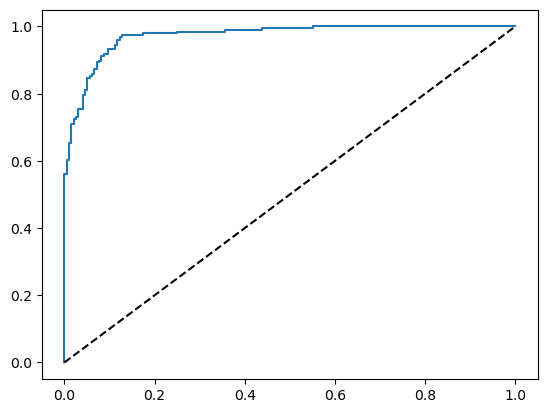

Linear train AUC is 0.9724854227405249


In [12]:
lin_preds = grid_lin.decision_function(X_t)
lin_fpr,lin_tpr,_ = roc_curve(Y,lin_preds)
lin_roc_auc = auc(lin_fpr,lin_tpr)
plt.plot(lin_fpr,lin_tpr)
plt.plot([0,1],[0,1],'k--')
plt.show()
print(f'Linear train AUC is {lin_roc_auc}')

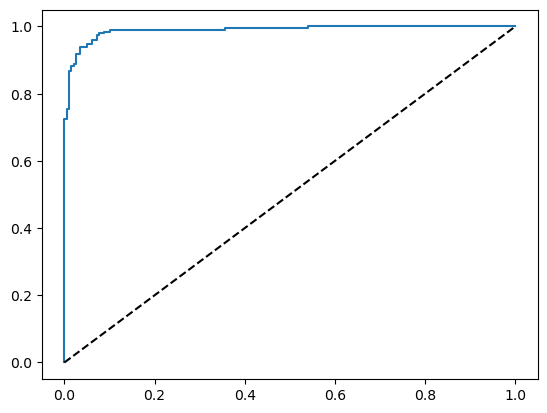

Radial train AUC is 0.9886765930862141


In [13]:
rbf_preds = rbf_best_model.decision_function(X_t)
rbf_fpr,rbf_tpr,_ = roc_curve(Y,rbf_preds)
rbf_roc_auc = auc(rbf_fpr,rbf_tpr)
plt.plot(rbf_fpr,rbf_tpr)
plt.plot([0,1],[0,1],'k--')
plt.show()
print(f'Radial train AUC is {rbf_roc_auc}')

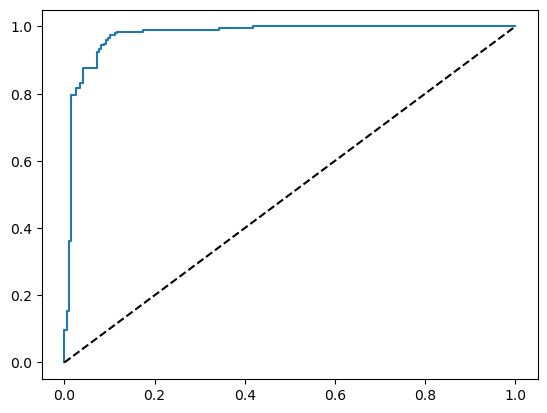

Polynomial train AUC is 0.9742555185339442


In [14]:
poly_preds = poly_best_model.decision_function(X_t)
poly_fpr,poly_tpr,_ = roc_curve(Y,poly_preds)
poly_roc_auc = auc(poly_fpr,poly_tpr)
plt.plot(poly_fpr,poly_tpr)
plt.plot([0,1],[0,1],'k--')
plt.show()
print(f'Polynomial train AUC is {poly_roc_auc}')

In [15]:
warnings.filterwarnings('ignore',message='X does not have valid feature names')

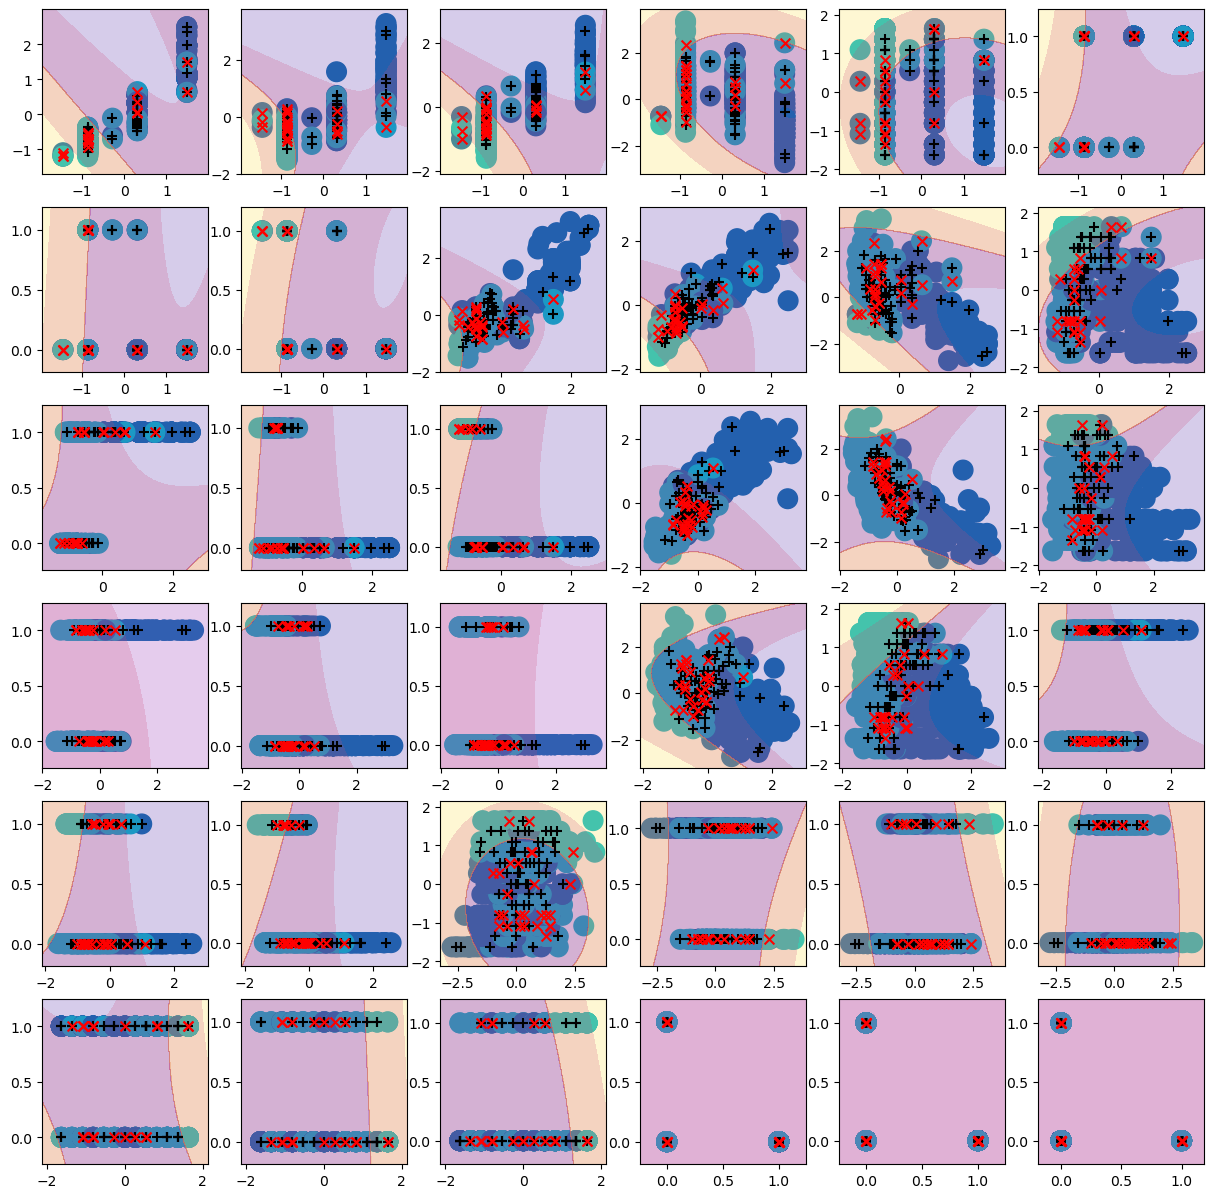

In [16]:
fig, ax = plt.subplots(6,6,figsize=(15,15))
ax = ax.flatten()

combs = combinations(range(X_t.shape[1]),2)
for i,c in enumerate(combs):
    plot_svm(X_t,Y,poly_best_model,features=c,ax=ax[i])

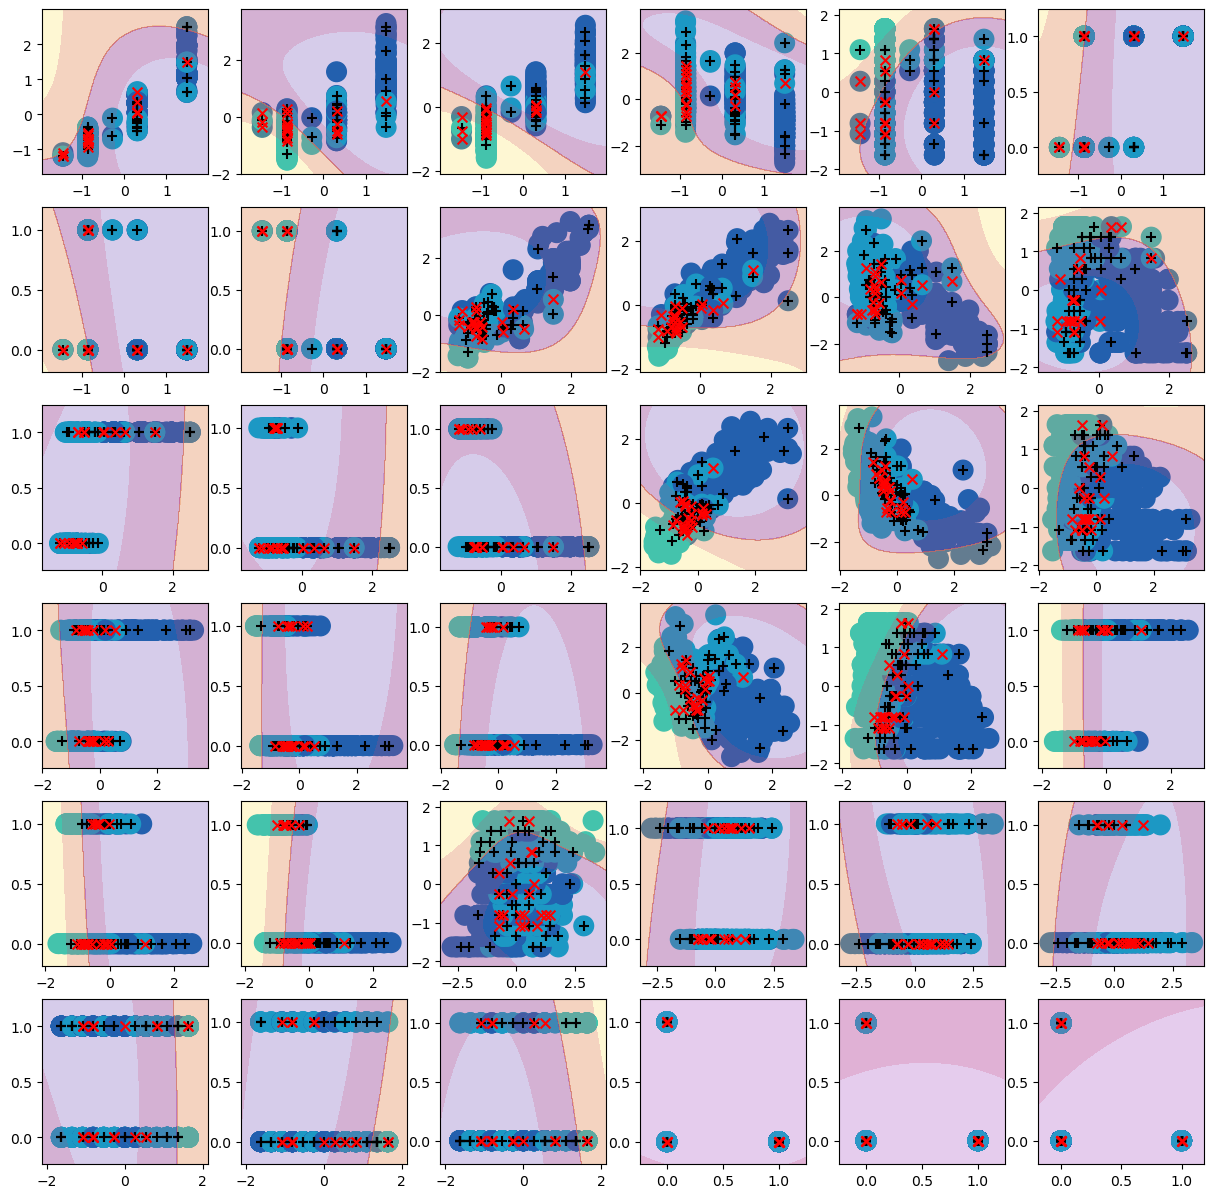

In [17]:
fig, ax = plt.subplots(6,6,figsize=(15,15))
ax = ax.flatten()

combs = combinations(range(X_t.shape[1]),2)
for i,c in enumerate(combs):
    plot_svm(X_t,Y,rbf_best_model,features=c,ax=ax[i])